# Mastering Support Vector Machines with Python and Scikit-Learn

https://www.youtube.com/watch?v=kPkwf1x7zpU

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# Code from video

mean1 = 55
std_dev1 = 10
num_samples = 500

column1_numbers = np.random.normal(mean1, std_dev1, num_samples)
column1_numbers = np.clip(column1_numbers, 30, 120)
column1_numbers = np.round(column1_numbers).astype(int)

mean2 = 18
std_dev2 = 3

column2_numbers = np.random.normal(mean2, std_dev2, num_samples)
column2_numbers = np.clip(column2_numbers, 12, 26)
column2_numbers = np.round(column2_numbers).astype(int)

column3_numbers = np.random.randint(2, size=num_samples)
column3_numbers[column1_numbers > mean1] =1

data = {"Miles_Per_week": column1_numbers,
        "Farthest_run": column2_numbers,
        "Qualified_Boston_Marathon": column3_numbers}

df = pd.DataFrame(data)
df

,Miles_Per_week,Farthest_run,Qualified_Boston_Marathon
0,55,14,0
1,61,16,1
2,65,17,1
3,44,18,1
4,59,14,1
...,...,...,...
495,52,18,1
496,67,13,1
497,62,17,1
498,59,24,1


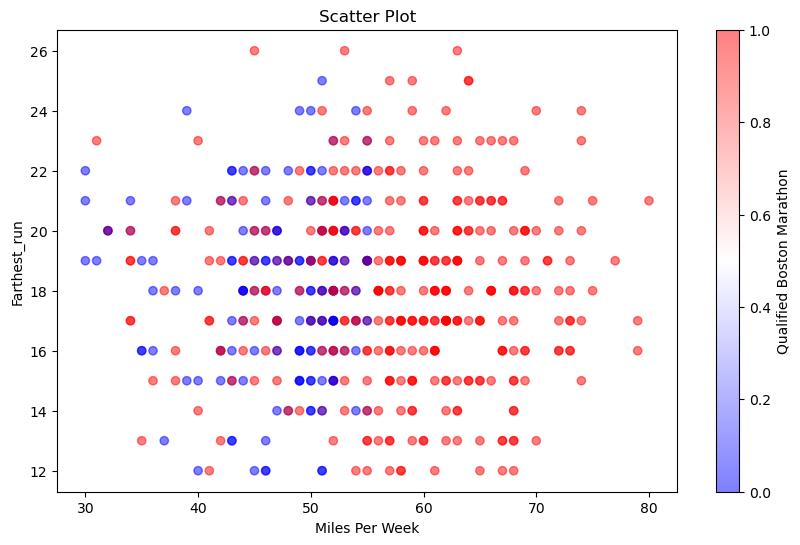

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Miles_Per_week'], df['Farthest_run'], c=df['Qualified_Boston_Marathon'], cmap='bwr', alpha=0.5)
plt.xlabel('Miles Per Week')
plt.ylabel('Farthest_run')
plt.title('Scatter Plot')
plt.colorbar(label='Qualified Boston Marathon')
plt.show()


In [8]:
X = df.iloc[:, 0:2]
X

,Miles_Per_week,Farthest_run
0,55,14
1,61,16
2,65,17
3,44,18
4,59,14
...,...,...
495,52,18
496,67,13
497,62,17
498,59,24


In [9]:
y = df.iloc[:, 2]
y

0      0
1      1
2      1
3      1
4      1
      ..
495    1
496    1
497    1
498    1
499    0
Name: Qualified_Boston_Marathon, Length: 500, dtype: int32

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
from sklearn.svm import SVC
model = SVC()
model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [17]:
model.score(X_test, y_test)

0.7

In [18]:
# Regularization
model_reg0 = SVC(C=0.1)
model_reg0.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [19]:
model_reg0.score(X_test, y_test)

0.71

In [20]:
model_reg1 = SVC(C=1)
model_reg1.fit(X_train, y_train)
model_reg1.score(X_test, y_test)

0.7

In [21]:
model_reg2 = SVC(C=1000)
model_reg2.fit(X_train, y_train)
model_reg2.score(X_test, y_test)

0.78

In [23]:
# Gamma
model_gamma0 = SVC(gamma=0.1)
model_gamma0.fit(X_train, y_train)
model_gamma0.score(X_test, y_test)

0.79

In [24]:
model_gamma1 = SVC(gamma=1)
model_gamma1.fit(X_train, y_train)
model_gamma1.score(X_test, y_test)

0.77

In [25]:
model_gamma2 = SVC(gamma=1000)
model_gamma2.fit(X_train, y_train)
model_gamma2.score(X_test, y_test)

0.76

In [26]:
# Kernel
model_linear = SVC(kernel='linear')
model_linear.fit(X_train, y_train)
model_linear.score(X_test, y_test)

0.71

In [27]:
model_linear = SVC(kernel='rbf')
model_linear.fit(X_train, y_train)
model_linear.score(X_test, y_test)

0.7